In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

In [52]:
ALGO = ['correction', 'detection_correction']
COMMODITY = ['cobalt_shift_20d', 'copper_shift_20d', 'magnesium_shift_20d', 'nickel_shift_20d']

In [53]:
plt.rcParams.update({
    'axes.titlesize': 18,  
    'axes.labelsize': 16,  
    'xtick.labelsize': 14, 
    'ytick.labelsize': 14,  
    'legend.fontsize': 14  
})

colors ={
    'orange': '#e97132',
    'blue':'#156082',
    'green': '#196b24'
}

fontsize = 12

In [54]:
def plot_ablation_barcharts(xlsx_path, algorithm, comm):
    comm = comm.split('_')[0]
    comm = comm.capitalize()    
    df = pd.read_excel(xlsx_path)
    
    fontsize = 10

    df['Exclude'] = df['Exclude'].fillna('None').astype(str)

    df = df[df['Exclude'] != 'RNN']
    df = df[df['Exclude'] != 'LSTM']
    df = df[df['Algorithm'] == 'detection_correction']
    df = df[df['Algorithm'] == algorithm]

    print(f"\n=== {comm} | {algorithm} ===")
    print(f"Rows after filtering: {len(df)}")

    models = df['Model'].unique()
    print(f"Models: {list(models)}")
    
    for model in models:
        
        model_df = df[df['Model'] == model]

        if model_df.empty:
            continue

        excluded_models = sorted(
            [str(x) for x in model_df['Exclude'].unique() if str(x) != 'None'],
            key=lambda x: (x != 'None')
        )

        if len(excluded_models) == 0:
            print(f"[SKIP] {model} → no ablations")
            continue

        prec_edcr = model_df.groupby('Exclude')['Precision (EDCR)'].mean().reindex(excluded_models + ['None'])
        rec_edcr = model_df.groupby('Exclude')['Recall (EDCR)'].mean().reindex(excluded_models + ['None'])

        if 'None' not in prec_edcr or 'None' not in rec_edcr:
            print(f"[SKIP] {model} → missing baseline")
            continue

        prec_edcr *= 100
        rec_edcr *= 100

        none_precision = prec_edcr['None']
        none_recall = rec_edcr['None']

        print(f"\n--- {comm} | {model} ---")
        print(f"Baseline: Precision={none_precision:.2f}, Recall={none_recall:.2f}")
        for m in excluded_models:
            print(f"Exclude {m}: "
                  f"Precision={prec_edcr[m]:.2f} ({prec_edcr[m]-none_precision:+.2f}), "
                  f"Recall={rec_edcr[m]:.2f} ({rec_edcr[m]-none_recall:+.2f})")

        barWidth = 0.35
        r1 = np.arange(len(prec_edcr) - 1)
        r2 = [x + barWidth for x in r1]

        plt.figure(figsize=(4.75,4.5))
        bars1 = plt.bar(r1, prec_edcr[excluded_models], color='grey', width=barWidth, edgecolor='black', zorder=1)
        bars2 = plt.bar(r2, rec_edcr[excluded_models], color='silver', width=barWidth, edgecolor='black', zorder=2)

        plt.axhline(y=none_precision, color='red', linestyle=(5, (10, 3)), linewidth=2)
        plt.axhline(y=none_recall, color='blue', linestyle='dotted', linewidth=2)

        for bar, value in zip(bars1, prec_edcr[excluded_models]):
            diff = value - none_precision
            sign = '+' if diff > 0 else '-' if diff < 0 else ''
            plt.text(bar.get_x() + bar.get_width()/2, value/2,
                     f'{sign}{abs(diff):.2f}%', ha='center', va='center',
                     color='white', fontsize=fontsize, rotation=90)

        for bar, value in zip(bars2, rec_edcr[excluded_models]):
            diff = value - none_recall
            sign = '+' if diff > 0 else '-' if diff < 0 else ''
            plt.text(bar.get_x() + bar.get_width()/2, value/2,
                     f'{sign}{abs(diff):.2f}%', ha='center', va='center',
                     color='black', fontsize=fontsize, rotation=90)

        plt.xlabel('Excluded Model', fontweight='bold', fontsize=fontsize)

        labels = [str(label).replace('CNNA', 'ATTN') for label in excluded_models]

        plt.xticks([r + barWidth/2 for r in range(len(prec_edcr) - 1)], labels, fontsize=fontsize)
        plt.yticks(fontsize=fontsize)
        plt.ylabel(f'Performance % ({comm})', fontweight='bold', fontsize=fontsize)
        plt.ylim([0, 100])

        precision_handle = mlines.Line2D([], [], color='red', linestyle=(5, (10, 3)), linewidth=2)
        recall_handle = mlines.Line2D([], [], color='blue', linestyle='dotted', linewidth=2)

        plt.legend(
            handles=[bars1, bars2, precision_handle, recall_handle],
            labels=['Precision (EDCR)', 'Recall (EDCR)', 'Precision (EDCR) - No Ablation', 'Recall (EDCR) - No Ablation'],
            loc='upper center', bbox_to_anchor=(0.5, -0.15),
            fancybox=True, ncol=2
        )

        ax = plt.gca()
        ax.spines['top'].set_color('none')
        ax.spines['right'].set_color('none')
        ax.spines['left'].set_color('gray')
        ax.spines['bottom'].set_color('gray')
        
        plt.xticks(rotation=0)
        plt.tight_layout()  
        plt.show()
        plt.close()


=== Cobalt | correction ===
Rows after filtering: 0
Models: []

=== Cobalt | detection_correction ===
Rows after filtering: 12
Models: ['CNN_256_filters_3_kernels_predictions', 'CNN_Attention_128_filters_5_kernels_predictions', 'LSTM_32_layers_predictions']

--- Cobalt | CNN_256_filters_3_kernels_predictions ---
Baseline: Precision=80.49, Recall=84.62
Exclude CNNA: Precision=82.54 (+2.05), Recall=66.67 (-17.95)
Exclude CNN: Precision=82.26 (+1.77), Recall=65.38 (-19.23)


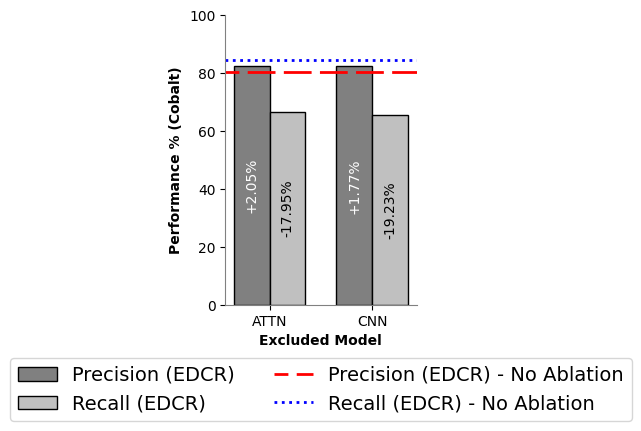


--- Cobalt | CNN_Attention_128_filters_5_kernels_predictions ---
Baseline: Precision=93.75, Recall=19.23
Exclude CNNA: Precision=94.12 (+0.37), Recall=20.51 (+1.28)
Exclude CNN: Precision=93.75 (+0.00), Recall=19.23 (+0.00)


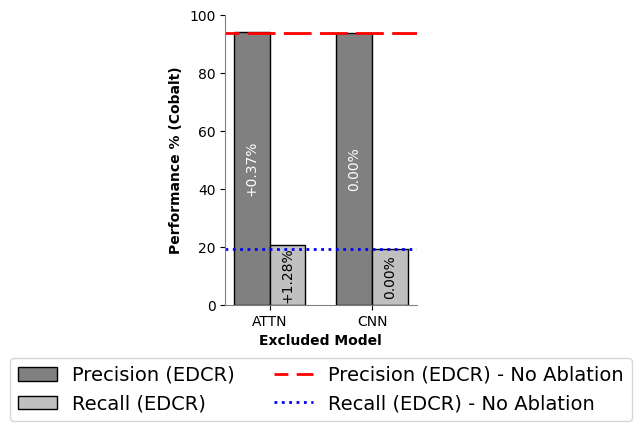


--- Cobalt | LSTM_32_layers_predictions ---
Baseline: Precision=69.41, Recall=75.64
Exclude CNNA: Precision=69.41 (+0.00), Recall=75.64 (+0.00)
Exclude CNN: Precision=69.41 (+0.00), Recall=75.64 (+0.00)


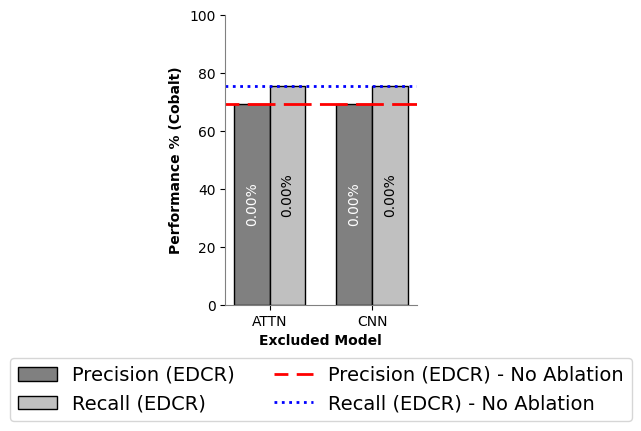


=== Copper | correction ===
Rows after filtering: 0
Models: []

=== Copper | detection_correction ===
Rows after filtering: 12
Models: ['CNN_Attention_32_filters_5_kernels_predictions', 'CNN_32_filters_3_kernels_predictions', 'CNN_64_filters_7_kernels_predictions', 'CNN_Attention_256_filters_5_kernels_predictions']

--- Copper | CNN_Attention_32_filters_5_kernels_predictions ---
Baseline: Precision=78.57, Recall=75.86
Exclude CNNA: Precision=78.57 (+0.00), Recall=75.86 (+0.00)
Exclude CNN: Precision=78.57 (+0.00), Recall=75.86 (+0.00)


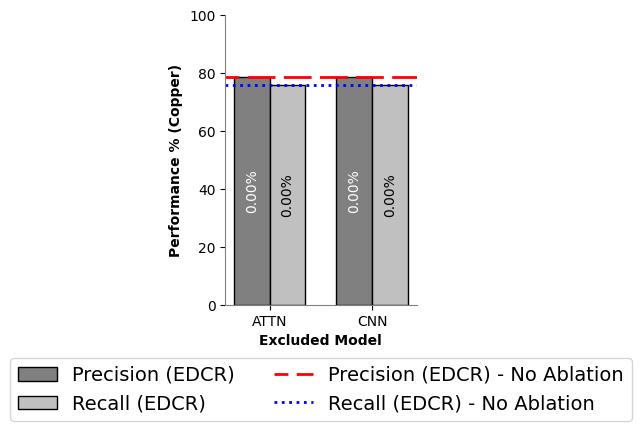


--- Copper | CNN_32_filters_3_kernels_predictions ---
Baseline: Precision=52.69, Recall=84.48
Exclude CNNA: Precision=52.33 (-0.36), Recall=77.59 (-6.90)
Exclude CNN: Precision=52.75 (+0.06), Recall=82.76 (-1.72)


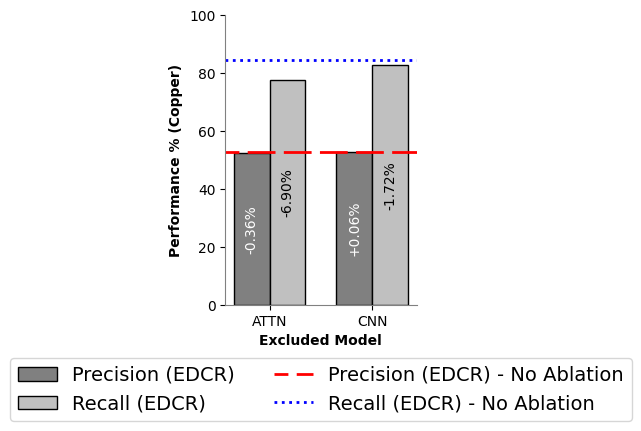


--- Copper | CNN_64_filters_7_kernels_predictions ---
Baseline: Precision=83.33, Recall=51.72
Exclude CNNA: Precision=84.21 (+0.88), Recall=55.17 (+3.45)
Exclude CNN: Precision=84.21 (+0.88), Recall=55.17 (+3.45)


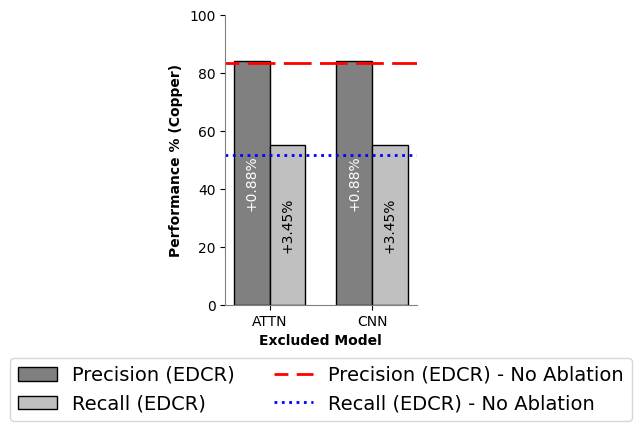


--- Copper | CNN_Attention_256_filters_5_kernels_predictions ---
Baseline: Precision=50.51, Recall=86.21
Exclude CNNA: Precision=29.41 (-21.09), Recall=8.62 (-77.59)
Exclude CNN: Precision=50.51 (+0.00), Recall=86.21 (+0.00)


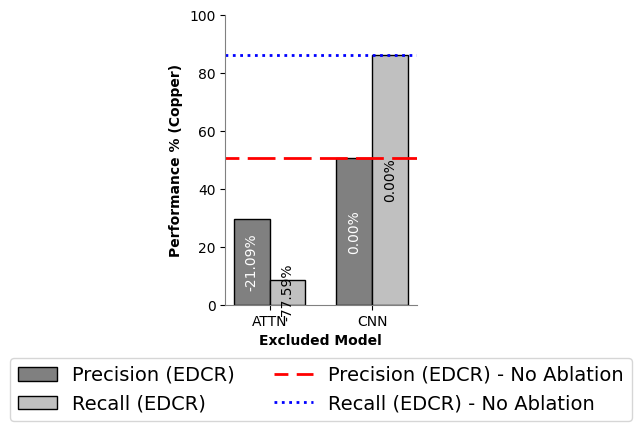


=== Magnesium | correction ===
Rows after filtering: 0
Models: []

=== Magnesium | detection_correction ===
Rows after filtering: 12
Models: ['CNN_32_filters_7_kernels_predictions', 'RNN_256_units_predictions', 'CNN_32_filters_5_kernels_predictions', 'LSTM_32_layers_predictions']

--- Magnesium | CNN_32_filters_7_kernels_predictions ---
Baseline: Precision=53.33, Recall=78.87
Exclude CNNA: Precision=52.22 (-1.11), Recall=66.20 (-12.68)
Exclude CNN: Precision=53.06 (-0.27), Recall=73.24 (-5.63)


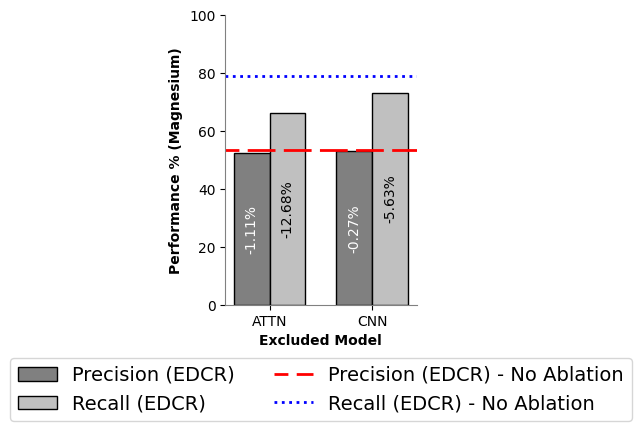


--- Magnesium | RNN_256_units_predictions ---
Baseline: Precision=19.72, Recall=100.00
Exclude CNNA: Precision=19.72 (+0.00), Recall=100.00 (+0.00)
Exclude CNN: Precision=19.72 (+0.00), Recall=100.00 (+0.00)


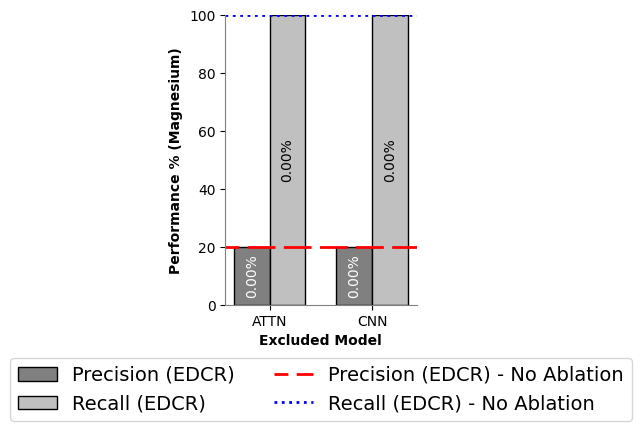


--- Magnesium | CNN_32_filters_5_kernels_predictions ---
Baseline: Precision=85.71, Recall=16.90
Exclude CNNA: Precision=85.71 (+0.00), Recall=16.90 (+0.00)
Exclude CNN: Precision=85.71 (+0.00), Recall=16.90 (+0.00)


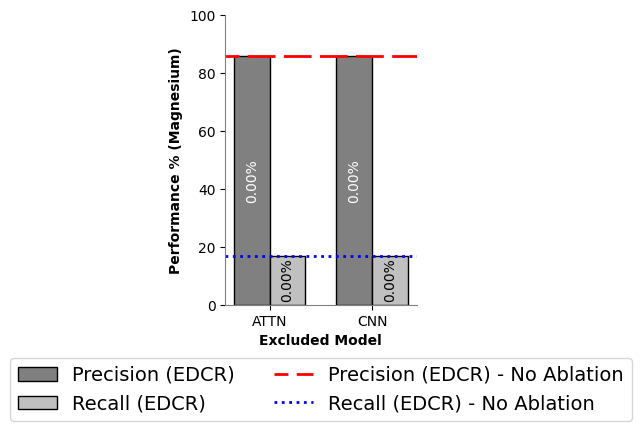


--- Magnesium | LSTM_32_layers_predictions ---
Baseline: Precision=76.92, Recall=28.17
Exclude CNNA: Precision=76.92 (+0.00), Recall=28.17 (+0.00)
Exclude CNN: Precision=76.92 (+0.00), Recall=28.17 (+0.00)


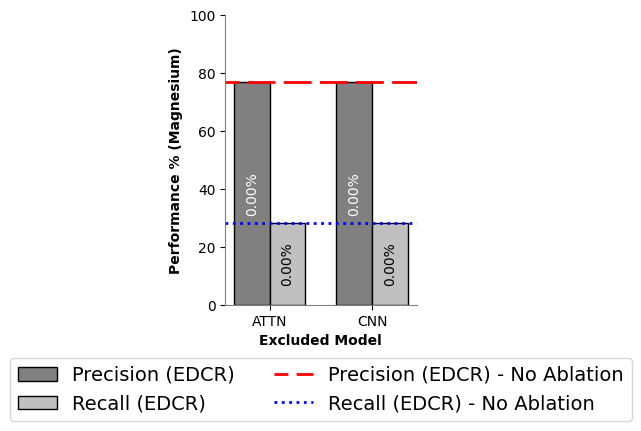


=== Nickel | correction ===
Rows after filtering: 0
Models: []

=== Nickel | detection_correction ===
Rows after filtering: 12
Models: ['CNN_Attention_64_filters_5_kernels_predictions', 'CNN_128_filters_3_kernels_predictions', 'CNN_Attention_128_filters_5_kernels_predictions', 'LSTM_32_layers_predictions']

--- Nickel | CNN_Attention_64_filters_5_kernels_predictions ---
Baseline: Precision=60.00, Recall=59.02
Exclude CNNA: Precision=61.11 (+1.11), Recall=54.10 (-4.92)
Exclude CNN: Precision=60.00 (+0.00), Recall=59.02 (+0.00)


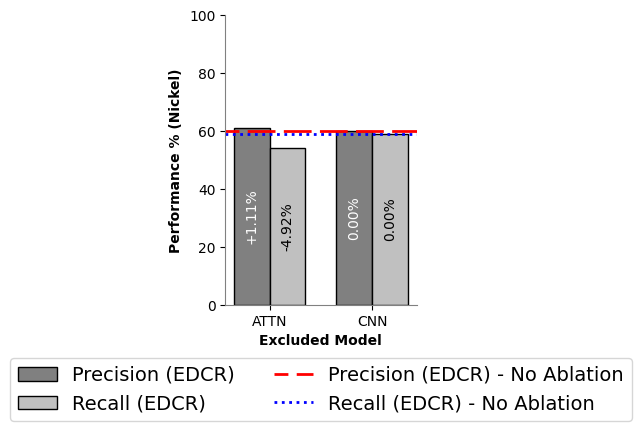


--- Nickel | CNN_128_filters_3_kernels_predictions ---
Baseline: Precision=39.62, Recall=68.85
Exclude CNNA: Precision=37.62 (-2.00), Recall=62.30 (-6.56)
Exclude CNN: Precision=38.05 (-1.57), Recall=70.49 (+1.64)


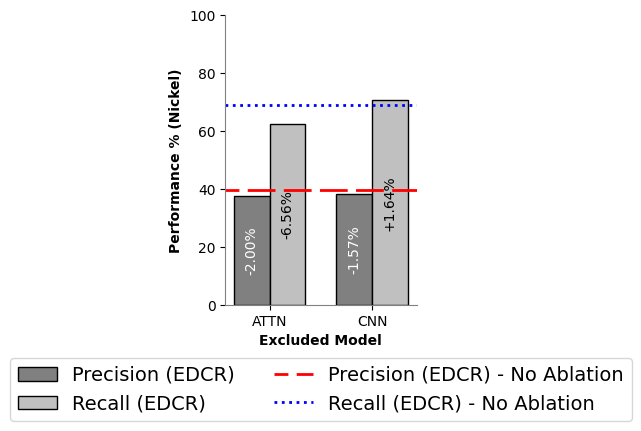


--- Nickel | CNN_Attention_128_filters_5_kernels_predictions ---
Baseline: Precision=67.57, Recall=40.98
Exclude CNNA: Precision=65.71 (-1.85), Recall=37.70 (-3.28)
Exclude CNN: Precision=68.42 (+0.85), Recall=42.62 (+1.64)


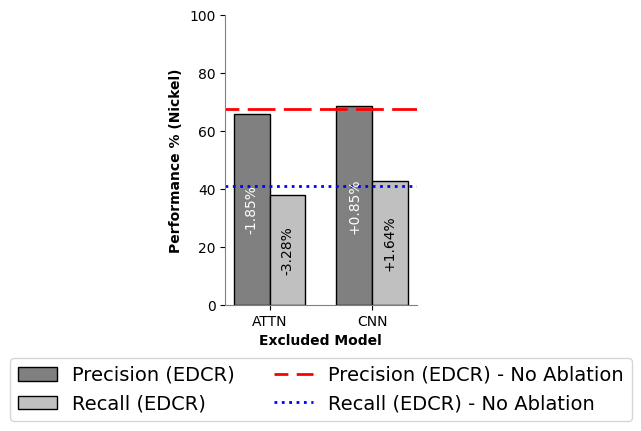


--- Nickel | LSTM_32_layers_predictions ---
Baseline: Precision=41.24, Recall=65.57
Exclude CNNA: Precision=41.24 (+0.00), Recall=65.57 (+0.00)
Exclude CNN: Precision=41.24 (+0.00), Recall=65.57 (+0.00)


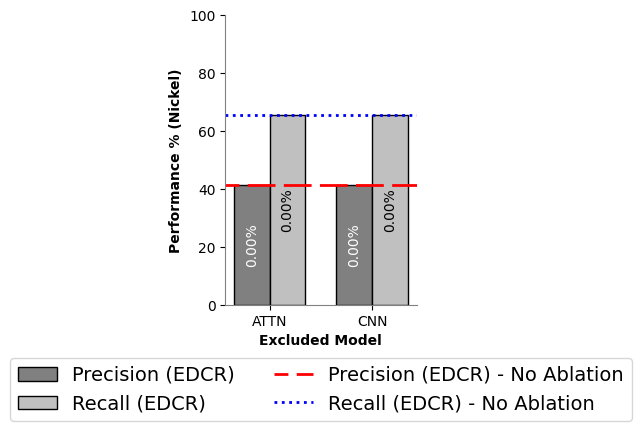

In [55]:
for comm in COMMODITY:
    for algo in ALGO:
        plot_ablation_barcharts(f'evaluation_results/top_f1/{comm}_results.xlsx', algo, comm)
        # plot_ablation_barcharts(f'evaluation_results/threshold/{comm}_results.xlsx', algo, comm)
